# UCI Gas Sensor Drift Dataset Visualization

This notebook explores the uploaded `batch1.dat` ... `batch10.dat` files for the **UCI Gas Sensor Drift** dataset.

It is designed to help with:
- dataset overview
- batch-wise drift inspection
- class distribution
- PCA / t-SNE structure
- feature drift over time/batches
- sensor-block summaries
- low-variance and high-drift feature discovery

These files are treated as **LIBSVM-style sparse files**:
- first token = class label
- remaining tokens = `feature_index:value`
- expected feature count here = **128**


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_svmlight_file
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_DIR = Path("../../data/gas+sensor+array+drift+dataset/Dataset")  # change if needed


In [2]:

def load_batch_file(path: Path) -> pd.DataFrame:
    X_sparse, y = load_svmlight_file(str(path), n_features=128, zero_based=False)
    X = X_sparse.toarray()
    cols = [f"f{i:03d}" for i in range(1, X.shape[1] + 1)]
    df = pd.DataFrame(X, columns=cols)
    df.insert(0, "label", y.astype(int))
    df.insert(0, "sample_in_batch", np.arange(len(df)))
    batch_num = int(path.stem.replace("batch", ""))
    df.insert(0, "batch", batch_num)
    return df

def load_all_batches(data_dir: Path) -> tuple[pd.DataFrame, list[Path]]:
    paths = sorted(data_dir.glob("batch*.dat"), key=lambda p: int(p.stem.replace("batch", "")))
    if not paths:
        raise FileNotFoundError(f"No batch*.dat files found in {data_dir}")
    frames = [load_batch_file(p) for p in paths]
    return pd.concat(frames, ignore_index=True), paths

def feature_columns(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if c.startswith("f")]

def sensor_block_mapping(n_features: int = 128, block_size: int = 8) -> dict[str, list[str]]:
    mapping = {}
    for sensor_idx in range(n_features // block_size):
        start = sensor_idx * block_size + 1
        end = start + block_size
        mapping[f"sensor_{sensor_idx + 1:02d}"] = [f"f{i:03d}" for i in range(start, end)]
    return mapping

def add_sensor_block_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    mapping = sensor_block_mapping()
    for sensor_name, cols in mapping.items():
        present = [c for c in cols if c in df.columns]
        df[f"{sensor_name}_mean"] = df[present].mean(axis=1)
        df[f"{sensor_name}_std"] = df[present].std(axis=1)
    return df

df, batch_paths = load_all_batches(DATA_DIR)
feats = feature_columns(df)

print("Loaded files:")
for p in batch_paths:
    print(" -", p.name)

print("\nShape:", df.shape)
print("Batches:", sorted(df["batch"].unique()))
print("Labels:", sorted(df["label"].unique()))
print("Feature count:", len(feats))
df.head()


Loaded files:
 - batch1.dat
 - batch2.dat
 - batch3.dat
 - batch4.dat
 - batch5.dat
 - batch6.dat
 - batch7.dat
 - batch8.dat
 - batch9.dat
 - batch10.dat

Shape: (13910, 131)
Batches: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Labels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Feature count: 128


,batch,sample_in_batch,label,f001,f002,f003,f004,f005,f006,f007,f008,f009,f010,f011,f012,f013,f014,f015,f016,f017,f018,f019,f020,f021,f022,f023,f024,f025,f026,f027,f028,f029,f030,f031,f032,f033,f034,f035,f036,f037,f038,f039,f040,f041,f042,f043,f044,f045,f046,f047,f048,f049,f050,f051,f052,f053,f054,f055,f056,f057,f058,f059,f060,f061,f062,f063,f064,f065,f066,f067,f068,f069,f070,f071,f072,f073,f074,f075,f076,f077,f078,f079,f080,f081,f082,f083,f084,f085,f086,f087,f088,f089,f090,f091,f092,f093,f094,f095,f096,f097,f098,f099,f100,f101,f102,f103,f104,f105,f106,f107,f108,f109,f110,f111,f112,f113,f114,f115,f116,f117,f118,f119,f120,f121,f122,f123,f124,f125,f126,f127,f128
0,1,0,1,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,-4.847512,15326.6914,1.768526,2.269085,2.713374,6.915721,-2.488324,-3.082212,-5.056975,2789.3831,2.754759,0.430440,0.649457,1.795029,-0.426662,-0.584313,-1.438976,2581.5686,2.680623,0.399746,0.605065,1.786704,-0.400115,-0.550743,-1.728611,685.3994,1.682904,0.122736,0.223703,0.584691,-0.138196,-0.236907,-0.781959,797.7738,1.742488,0.152483,0.218904,0.841862,-0.164646,-0.315720,-0.791447,3128.8489,3.605537,0.532422,0.763062,2.118983,-0.557197,-0.809953,-2.344130,3136.8778,3.555169,0.535883,0.761388,1.499244,-0.571480,-0.944425,-2.658358,13540.6738,1.765738,2.006883,2.519022,6.261430,-2.172101,-2.694967,-3.791499,13831.7539,1.746493,2.057165,2.391239,5.695234,-2.350776,-2.888766,-8.129869,3020.9191,2.819354,0.474520,0.723993,2.160130,-0.467900,-0.638167,-1.643650,2185.9741,2.949381,0.342575,0.515090,1.340477,-0.361030,-0.493482,-1.200617,862.7479,1.779291,0.165138,0.246473,1.358106,-0.187465,-0.416382,-1.058061,1059.7562,1.896047,0.198946,0.334017,0.815048,-0.204467,-0.345119,-0.969336,3357.1124,3.860647,0.580818,0.806830,1.729739,-0.619214,-1.071137,-3.037772,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529
1,1,1,1,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,-7.518333,23855.7812,2.164706,4.901063,5.971392,6.978131,-4.199424,-5.221090,-7.604863,3882.9057,3.155054,0.802987,1.172245,1.570895,-0.697881,-0.944655,-1.334743,3651.0427,3.130669,0.739278,1.101765,1.428631,-0.659641,-0.915543,-1.334217,982.9490,1.933877,0.233308,0.378052,0.717916,-0.225572,-0.354591,-0.748061,1162.2378,2.039431,0.278337,0.486908,0.840494,-0.271369,-0.473164,-0.718214,4332.1543,3.990162,1.002503,1.586233,1.926608,-0.913245,-1.335612,-1.773328,4387.5284,4.011519,1.009769,1.647830,1.962858,-0.944028,-1.631468,-1.925095,20553.5645,2.108870,4.266941,5.185937,6.398693,-3.636176,-4.497039,-7.464548,22540.1933,2.222146,4.621283,5.573620,6.756039,-3.986434,-4.953663,-6.561748,4240.3011,3.262893,0.887237,1.297617,1.630074,-0.768036,-1.244472,-1.419646,3079.0621,3.399659,0.649639,0.948781,1.369550,-0.598444,-0.820868,-1.081919,1237.0131,2.067927,0.305793,0.558008,0.948564,-0.289557,-0.501078,-1.191404,1459.6356,2.149242,0.361007,0.614619,0.950204,-0.327339,-0.503861,-0.838039,4685.7753,4.277604,1.080629,1.818559,2.237534,-1.004812,-1.530519,-1.994993,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225
2,1,2,1,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,-12.230939,37562.3008,2.840403,7.386357,9.511703,12.129657,-6.689464,-8.184333,-10.196169,5476.3898,3.929721,1.132118,1.717418,2.050157,-1.052941,-1.436270,-1.956262,5140.8302,3.880357,1.054304,1.649600,1.964727,-0.995282,-1.377502,-1.844021,1409.2183,2.316449,0.335154,0.572576,0.932730,-0.337312,-0.532147,-1.011991,1647.6780,2.443898,0.405582,0.725644,1.006433,-0.403554,-0.676717,-1.008518,6145.6659,4.998625,1.426344,2.407405,2.856787,-1.377070,-1.994748,-2.445191,6197.3047,4.997810,1.473118,2.545978,3.331699,-1.420663,-2.185120,-2.625092,32366.9336,2.742087,6.419288,8.290210,9.709606,-5.792984,-7.171543,-9.797253,35597.0020,2.916899,6.969954,8.951225,10.413684,-6.441517,-7.914062,-9.973361,5968.8666,4.056138,1.262938,1.935885,2.346947,-1.159097,-1.791556,-2.233596,4409.1721,4.286887,0.9178

## Dataset overview

In [3]:

batch_summary = (
    df.groupby("batch")
      .agg(n_samples=("label", "size"), n_classes=("label", "nunique"))
      .reset_index()
)
batch_summary


,batch,n_samples,n_classes
0,1,445,6
1,2,1244,6
2,3,1586,5
3,4,161,5
4,5,197,5
5,6,2300,6
6,7,3613,6
7,8,294,6
8,9,470,6
9,10,3600,6


In [4]:

class_dist = pd.crosstab(df["batch"], df["label"])
class_dist


label,1,2,3,4,5,6
batch,,,,,,
1,90,98,83,30,70,74
2,164,334,100,109,532,5
3,365,490,216,240,275,0
4,64,43,12,30,12,0
5,28,40,20,46,63,0
6,514,574,110,29,606,467
7,649,662,360,744,630,568
8,30,30,40,33,143,18
9,61,55,100,75,78,101


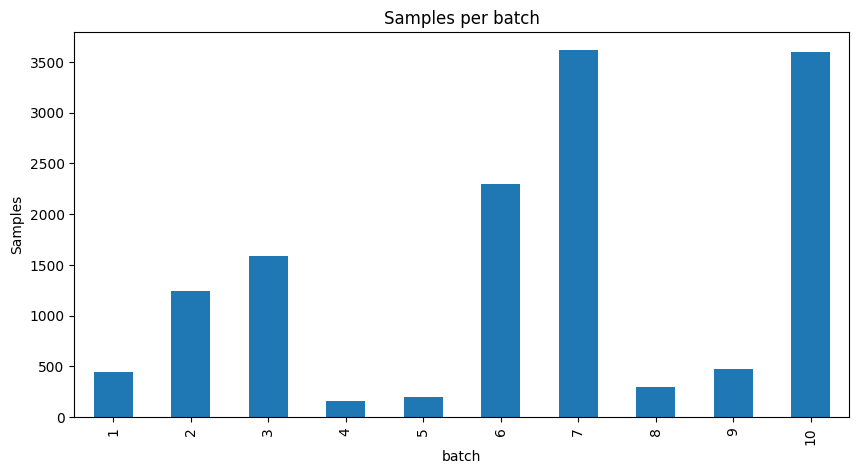

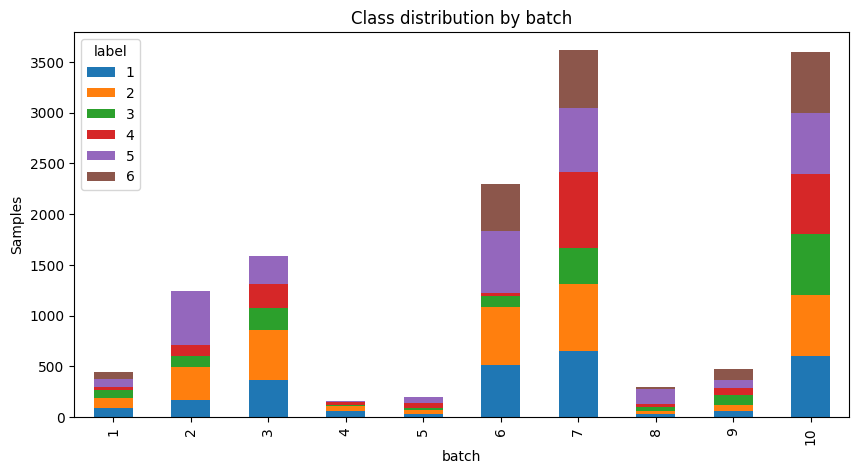

In [5]:

batch_summary.plot(x="batch", y="n_samples", kind="bar", legend=False, title="Samples per batch")
plt.ylabel("Samples")
plt.show()

class_dist.plot(kind="bar", stacked=True, title="Class distribution by batch")
plt.ylabel("Samples")
plt.show()


## Feature quality and simple statistics

In [6]:

feature_summary = pd.DataFrame({
    "feature": feats,
    "mean": df[feats].mean().values,
    "std": df[feats].std().values,
    "min": df[feats].min().values,
    "max": df[feats].max().values,
    "missing_ratio": df[feats].isna().mean().values,
    "zero_ratio": (df[feats] == 0).mean().values,
    "batch_mean_variance": df.groupby("batch")[feats].mean().var().values,
}).sort_values("batch_mean_variance", ascending=False)

feature_summary.head(20)


,feature,mean,std,min,max,missing_ratio,zero_ratio,batch_mean_variance
0,f001,50435.066174,69844.785952,-16757.598600,670687.347700,0.0,0.000000,1.823814e+09
8,f009,57340.104585,64045.265134,-16119.460900,502202.812500,0.0,0.000000,8.410584e+08
72,f073,38251.212746,47349.945833,-3487.938500,490020.023400,0.0,0.000000,7.921227e+08
64,f065,46455.972918,51386.395589,-4441.292900,463858.121000,0.0,0.000000,6.549631e+08
112,f113,22366.505846,16603.686992,-9231.119100,113301.915800,0.0,0.000000,8.802930e+07
120,f121,19688.565373,14281.652395,-8297.548800,96706.792700,0.0,0.000000,7.094197e+07
56,f057,20602.556453,13840.867682,-18973.406300,86587.815400,0.0,0.000000,6.502461e+07
48,f049,19495.893697,13255.292911,-17594.230500,83191.154300,0.0,0.000000,5.720200e+07
80,f081,18148.821469,13509.725928,-9959.816400,87508.149400,0.0,0.000000,5.402005e+07
16,f017,16204.100366,11419.266483,-22110.726500,71110.771500,0.0,0.000000,3.965708e+07


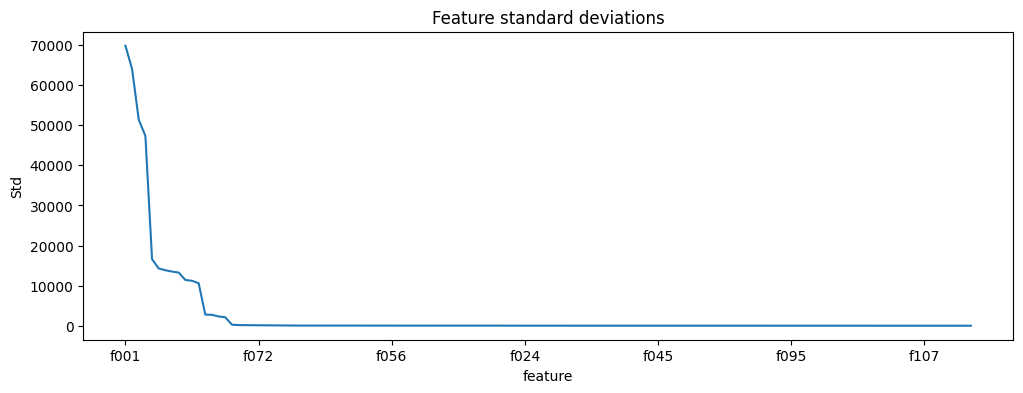

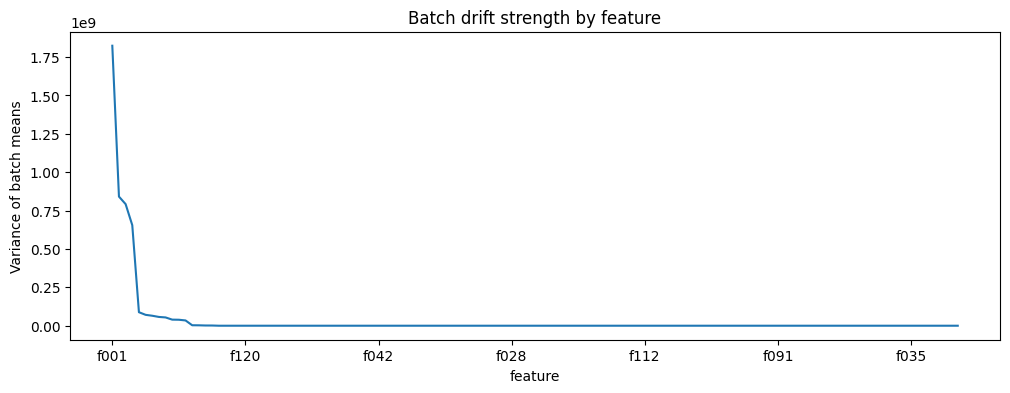

In [7]:

fig, ax = plt.subplots(figsize=(12, 4))
feature_summary.set_index("feature")["std"].sort_values(ascending=False).plot(ax=ax)
ax.set_title("Feature standard deviations")
ax.set_ylabel("Std")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
feature_summary.set_index("feature")["batch_mean_variance"].sort_values(ascending=False).plot(ax=ax)
ax.set_title("Batch drift strength by feature")
ax.set_ylabel("Variance of batch means")
plt.show()


## PCA structure

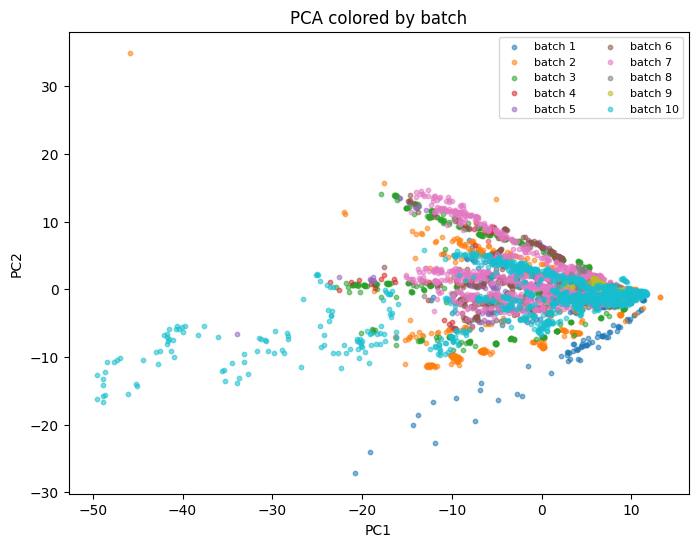

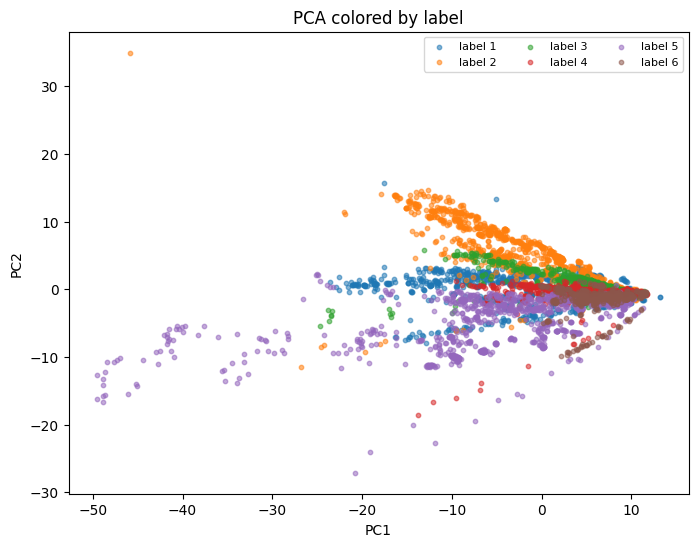

In [8]:

sample_cap = 5000
work = df.sample(min(sample_cap, len(df)), random_state=42).sort_index()

Xs = StandardScaler().fit_transform(work[feats].to_numpy())
pcs = PCA(n_components=2, random_state=42).fit_transform(Xs)
work = work.copy()
work["pc1"] = pcs[:, 0]
work["pc2"] = pcs[:, 1]

plt.figure(figsize=(8, 6))
for batch, grp in work.groupby("batch"):
    plt.scatter(grp["pc1"], grp["pc2"], s=10, alpha=0.55, label=f"batch {batch}")
plt.title("PCA colored by batch")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(ncol=2, fontsize=8)
plt.show()

plt.figure(figsize=(8, 6))
for label, grp in work.groupby("label"):
    plt.scatter(grp["pc1"], grp["pc2"], s=10, alpha=0.55, label=f"label {label}")
plt.title("PCA colored by label")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(ncol=3, fontsize=8)
plt.show()


## t-SNE structure

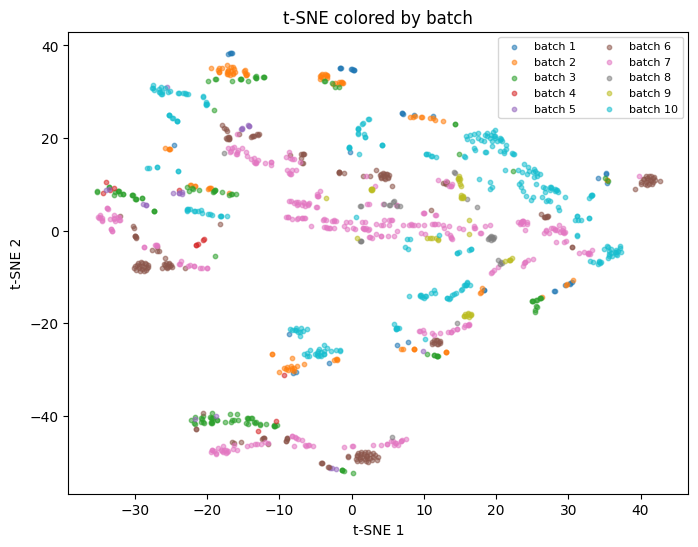

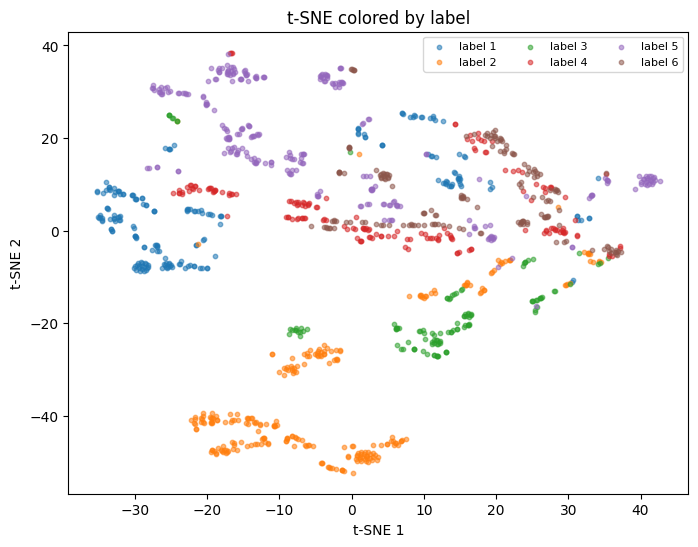

In [9]:

sample_cap = 1200
work2 = df.sample(min(sample_cap, len(df)), random_state=42).sort_index()

Xs2 = StandardScaler().fit_transform(work2[feats].to_numpy())
Xp2 = PCA(n_components=min(30, Xs2.shape[1]), random_state=42).fit_transform(Xs2)
emb = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto", perplexity=min(30, max(5, len(work2)//20))).fit_transform(Xp2)
work2 = work2.copy()
work2["tsne1"] = emb[:, 0]
work2["tsne2"] = emb[:, 1]

plt.figure(figsize=(8, 6))
for batch, grp in work2.groupby("batch"):
    plt.scatter(grp["tsne1"], grp["tsne2"], s=10, alpha=0.55, label=f"batch {batch}")
plt.title("t-SNE colored by batch")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(ncol=2, fontsize=8)
plt.show()

plt.figure(figsize=(8, 6))
for label, grp in work2.groupby("label"):
    plt.scatter(grp["tsne1"], grp["tsne2"], s=10, alpha=0.55, label=f"label {label}")
plt.title("t-SNE colored by label")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(ncol=3, fontsize=8)
plt.show()


## Drift over batches

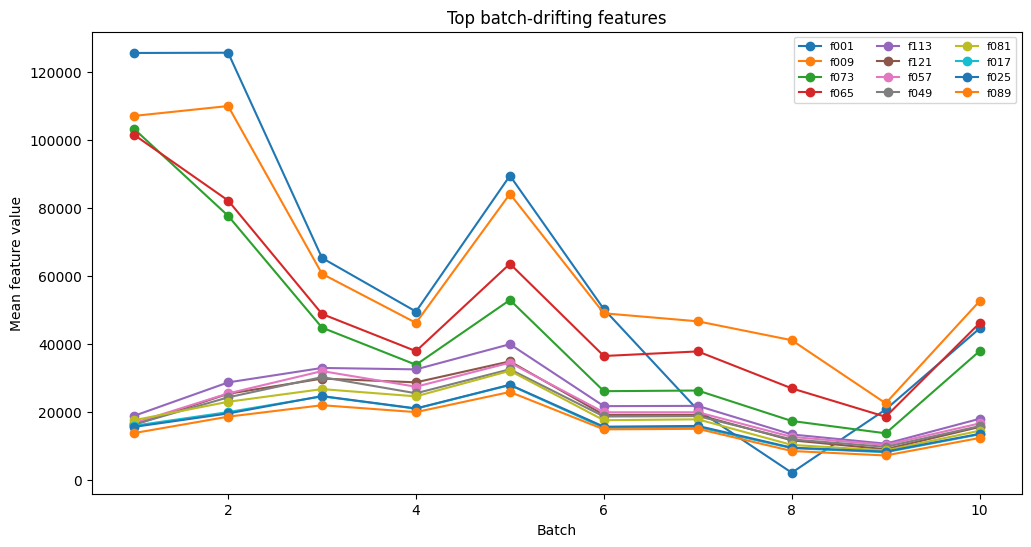

In [10]:

top_drift_feats = feature_summary.head(12)["feature"].tolist()
batch_means = df.groupby("batch")[top_drift_feats].mean()

plt.figure(figsize=(12, 6))
for col in batch_means.columns:
    plt.plot(batch_means.index, batch_means[col], marker="o", label=col)
plt.title("Top batch-drifting features")
plt.xlabel("Batch")
plt.ylabel("Mean feature value")
plt.legend(ncol=3, fontsize=8)
plt.show()


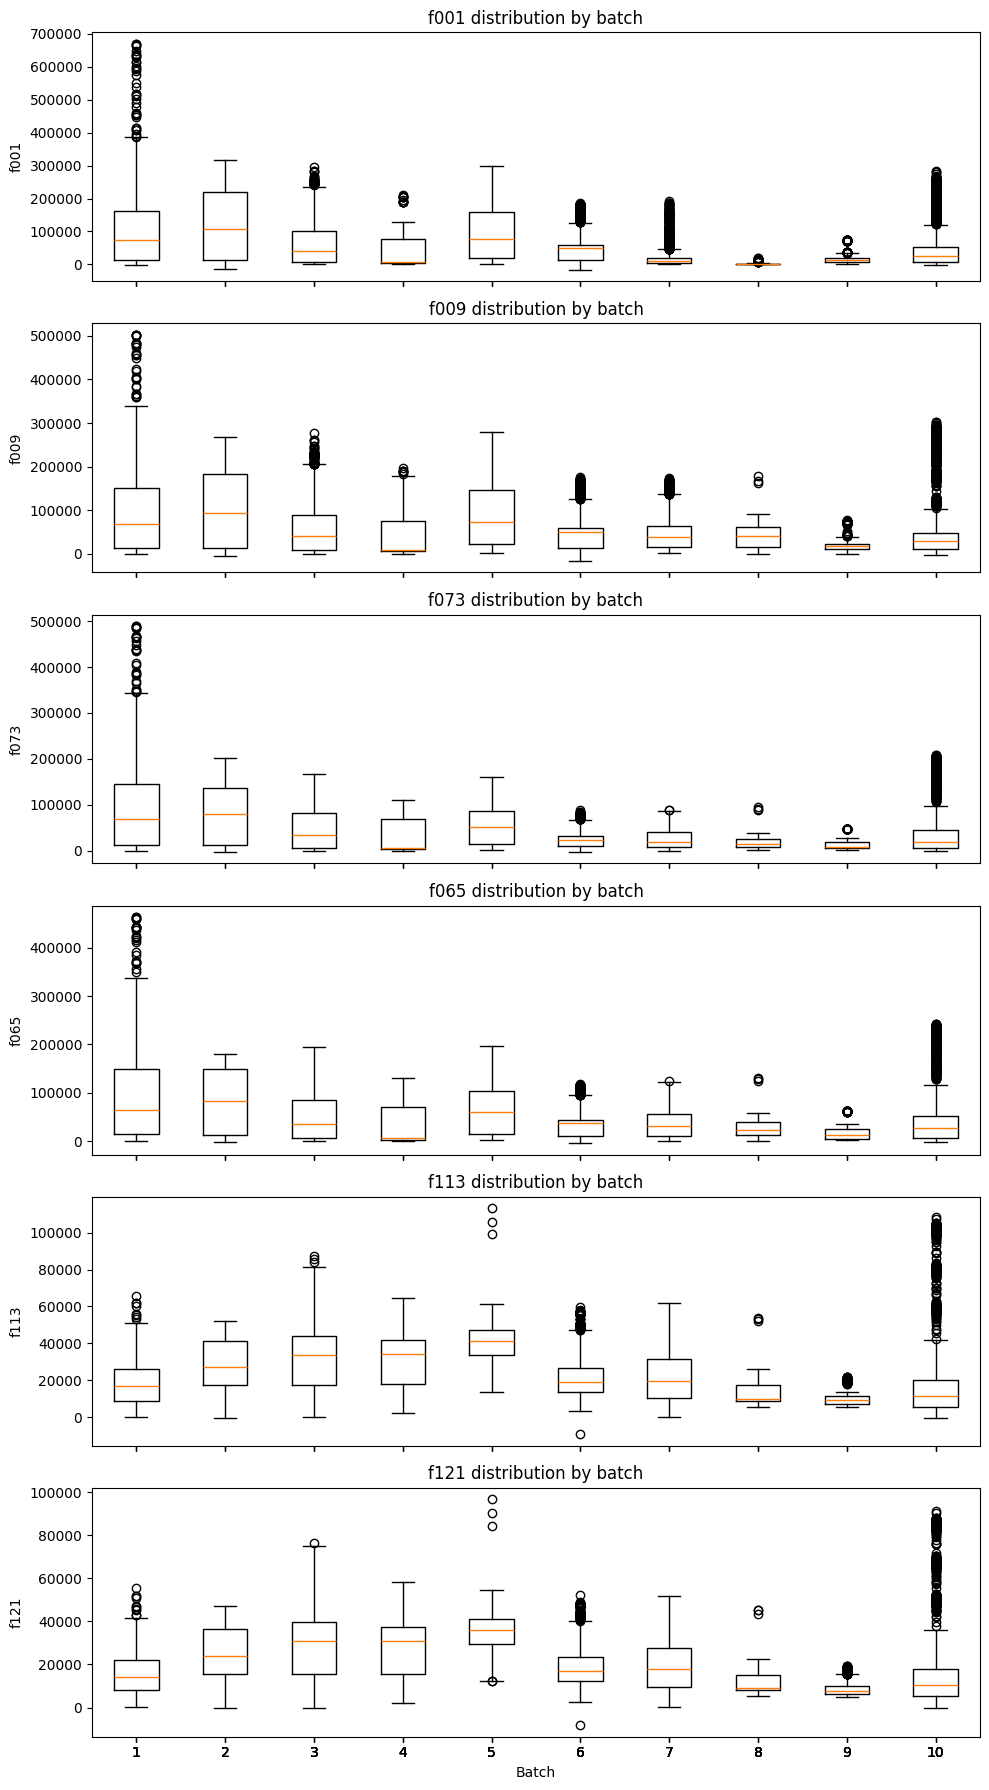

In [11]:

fig, axes = plt.subplots(6, 1, figsize=(10, 18), sharex=True)
for ax, feat in zip(axes, top_drift_feats[:6]):
    groups = [grp[feat].values for _, grp in df.groupby("batch")]
    ax.boxplot(groups, tick_labels=sorted(df["batch"].unique()))
    ax.set_title(f"{feat} distribution by batch")
    ax.set_ylabel(feat)
axes[-1].set_xlabel("Batch")
plt.tight_layout()
plt.show()


## Sensor-block summaries (128 features -> 16 blocks of 8 features)

In [12]:

df_blocks = add_sensor_block_features(df)
sensor_mean_cols = [c for c in df_blocks.columns if c.startswith("sensor_") and c.endswith("_mean")]
batch_sensor = df_blocks.groupby("batch")[sensor_mean_cols].mean()
batch_sensor.head()


,sensor_01_mean,sensor_02_mean,sensor_03_mean,sensor_04_mean,sensor_05_mean,sensor_06_mean,sensor_07_mean,sensor_08_mean,sensor_09_mean,sensor_10_mean,sensor_11_mean,sensor_12_mean,sensor_13_mean,sensor_14_mean,sensor_15_mean,sensor_16_mean
batch,,,,,,,,,,,,,,,,
1,15699.151941,13386.358800,1988.656334,1946.304114,490.691775,559.506931,2035.528913,2087.255321,12688.795066,12905.155207,2192.593345,1718.305367,553.498254,589.425495,2353.921978,2023.924114
2,15702.137356,13743.225883,2490.355835,2441.756973,661.219874,654.085284,3034.440763,3179.367181,10271.820540,9708.895904,2869.684866,2321.446507,767.999981,796.001272,3583.083129,3163.756441
3,8156.701840,7574.382408,3069.865620,3080.418409,591.227962,580.204974,3779.823613,4001.649612,6098.623590,5596.301589,3336.673592,2743.738225,813.340478,878.142657,4117.133207,3724.449378
4,6172.382433,5762.022797,2615.340861,2623.923958,523.086863,529.288500,3181.271752,3419.766490,4724.069845,4223.472169,3067.743840,2488.300825,855.854283,886.288819,4059.753357,3583.259684
5,11180.794433,10513.099781,3487.329407,3494.836412,684.967838,658.451428,4066.824527,4309.924915,7944.132864,6612.067259,4009.463601,3230.256158,997.466467,1026.911937,4989.720386,4357.150028


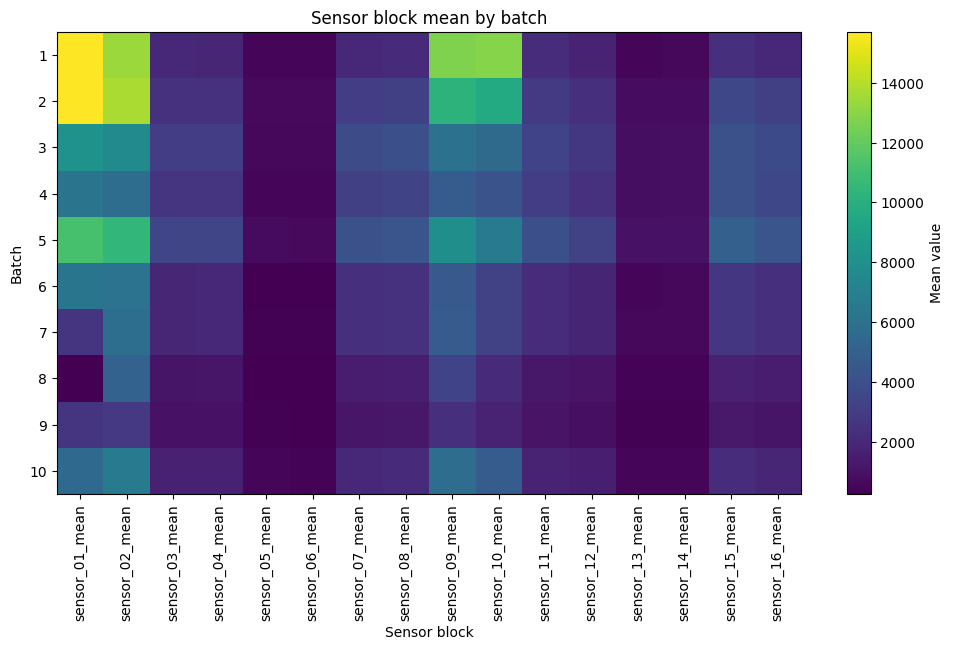

In [13]:

plt.figure(figsize=(12, 6))
plt.imshow(batch_sensor.to_numpy(), aspect="auto")
plt.colorbar(label="Mean value")
plt.title("Sensor block mean by batch")
plt.xlabel("Sensor block")
plt.ylabel("Batch")
plt.xticks(range(len(sensor_mean_cols)), sensor_mean_cols, rotation=90)
plt.yticks(range(len(batch_sensor.index)), batch_sensor.index)
plt.show()


## Batch-label interaction

In [14]:

class_batch = df.groupby(["batch", "label"])[feats].mean().mean(axis=1).unstack("label")
class_batch


label,1,2,3,4,5,6
batch,,,,,,
1,3860.123884,1758.241475,1741.921843,7475.096779,11724.323401,4420.967540
2,4424.830962,1976.686493,1534.299749,3725.665787,7321.776557,4183.621629
3,4750.043873,2481.207282,1383.052816,3185.543457,6365.692558,NaN
4,3444.833812,2023.205113,1375.205313,2535.625830,7513.715122,NaN
5,5189.865724,2325.857078,2207.965631,4023.204087,6564.239793,NaN
6,2755.972353,1626.026499,1625.385807,3237.270179,3447.652593,2156.036813
7,3060.045053,2040.308921,913.263571,1722.223953,3923.891452,1333.400454
8,859.479493,705.451817,1419.710517,1550.451133,1811.708955,669.155849
9,850.136560,555.617429,1005.839955,1564.720754,2373.075231,934.430129


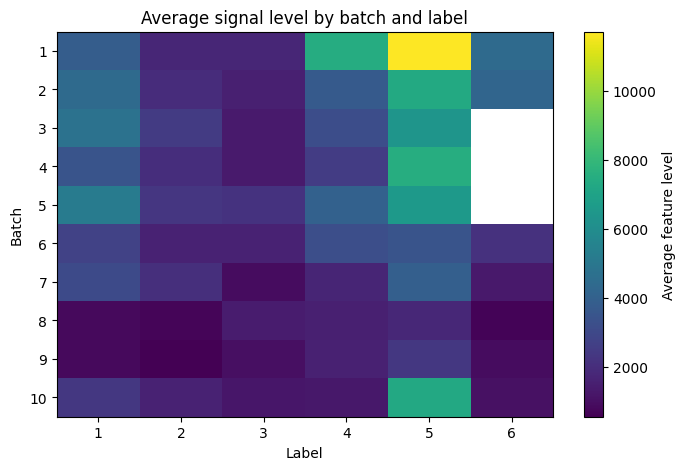

In [15]:

plt.figure(figsize=(8, 5))
plt.imshow(class_batch.to_numpy(), aspect="auto")
plt.colorbar(label="Average feature level")
plt.title("Average signal level by batch and label")
plt.xlabel("Label")
plt.ylabel("Batch")
plt.xticks(range(len(class_batch.columns)), class_batch.columns)
plt.yticks(range(len(class_batch.index)), class_batch.index)
plt.show()


## Save CSV summaries

In [19]:
OUT_DIR = Path(".") / "gas_sensor_drift_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

batch_summary.to_csv(OUT_DIR / "batch_summary.csv", index=False)
feature_summary.to_csv(OUT_DIR / "feature_summary.csv", index=False)

print("Saved:")
print(OUT_DIR / "batch_summary.csv")
print(OUT_DIR / "feature_summary.csv")


Saved:
gas_sensor_drift_outputs\batch_summary.csv
gas_sensor_drift_outputs\feature_summary.csv
